# MicroFactual — End-to-End Feature Tour

This notebook exercises **every major feature** of MicroFactual on a *real* microbiome
dataset (Zeller et al. 2014 colorectal-cancer stool metagenomes), so it doubles as a
smoke test and a guided tour.

**What we cover**
1. Loading a real dataset with `MicrobiomeDataset`
2. Data exploration (`get_info`) and cutoff diagnostics (`mf.explore`)
3. Microbiome-aware preprocessing transforms (abundance / prevalence / CLR)
4. sklearn-native usage — `Pipeline`, `cross_validate`, `GridSearchCV`
5. The one-liner `mf.classify()` API
6. Train / test evaluation with `MicrobiomeClassifier`
7. Visualization — ROC, confusion matrix, feature importance
8. **Counterfactual explanations** (the headline feature): sparse, actionable per-sample
   `mf.explain_counterfactual()`, plausibility bounds + `mf.plot_counterfactual_heatmap()`,
   and cohort-level `mf.counterfactual_importance()`
9. Comparing algorithms (random forest vs. logistic regression)

> The dataset ships in `datasets/` (`abundance_crc.txt`, `metadata_crc.txt`).
> The counterfactual section requires the optional extra:
> `pip install 'microfactual[explainability]'`.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import microfactual as mf

warnings.filterwarnings("ignore")  # keep the tour output clean
print("MicroFactual version:", mf.__version__)

MicroFactual version: 0.2.0


## 1. Load a real dataset

`MicrobiomeDataset.from_files` reads a species×samples abundance table and a metadata table, aligns them on the sample column, and gives sklearn-shaped `X` (samples×features) and encoded `y`.

In [2]:
ABUNDANCE = "../datasets/abundance_crc.txt"
METADATA = "../datasets/metadata_crc.txt"

dataset = mf.MicrobiomeDataset.from_files(
    abundance_file=ABUNDANCE,
    metadata_file=METADATA,
    target_column="Group",       # CRC vs Control
    sample_column="Sample ID",
)
print(dataset)
print("\nTarget classes:", dataset.target_names)

MicrobiomeDataset Summary:
  Samples: 141
  Features: 1753
  Target: Group (2 classes)
  Sparsity: 90.83%
  Preprocessing steps: 0

Target classes: ['CRC', 'Control']


## 2. Explore the data

`get_info()` returns dimensions, class balance, sparsity and read-depth statistics — useful sanity checks for compositional data.

In [3]:
info = dataset.get_info()
for key in [
    "n_samples", "n_features", "target_classes", "class_distribution",
    "sparsity", "mean_features_per_sample",
]:
    print(f"{key:>26}: {info[key]}")

X, y = dataset.X, dataset.y
print("\nX shape:", X.shape, "| y distribution:", dict(y.value_counts()))

                 n_samples: 141
                n_features: 1753
            target_classes: ['CRC', 'Control']
        class_distribution: {'Control': 88, 'CRC': 53}
                  sparsity: 0.9083273658530665
  mean_features_per_sample: 160.70212765957447

X shape: (141, 1753) | y distribution: {1: 88, 0: 53}


### Choosing preprocessing cutoffs visually

Before committing to filter thresholds, `mf.explore()` shows how per-taxon
abundance and prevalence are distributed and overlays the proposed cutoffs.
The **log-abundance histogram is typically bimodal** — the trough between the
noise mode and the signal mode is a natural place to set the abundance cutoff.
The scatter reports how many taxa survive both filters together.

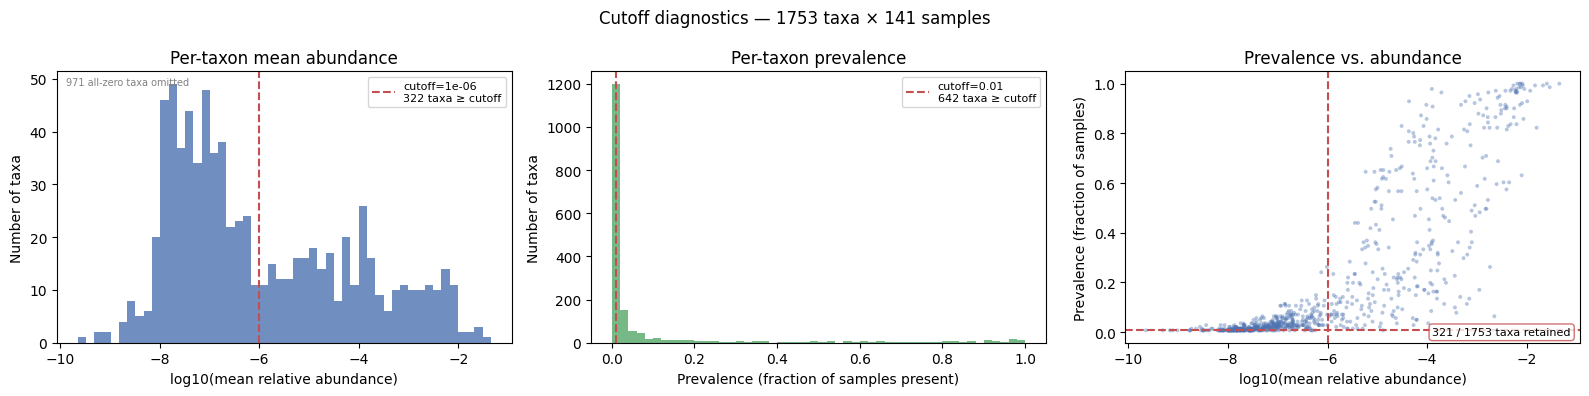

In [4]:
# Defaults match AbundanceFilter(min_abundance=1e-6) / PrevalenceFilter(0.01)
fig = mf.explore(dataset, abundance_cutoff=1e-6, prevalence_cutoff=0.01)
plt.show()

## 3. Microbiome-aware preprocessing

The transforms are plain sklearn transformers, usable standalone or in a `Pipeline`:
- **`AbundanceFilter`** — drop very-low-abundance features
- **`PrevalenceFilter`** — drop features present in too few samples
- **`CLRTransform`** — centered log-ratio transform for compositional data

In [5]:
from microfactual import AbundanceFilter, CLRTransform, PrevalenceFilter

step1 = AbundanceFilter(min_abundance=1e-6).fit_transform(X)
step2 = PrevalenceFilter(min_prevalence=0.01).fit_transform(step1)
step3 = CLRTransform().fit_transform(step2)

print(f"Raw features:            {X.shape[1]}")
print(f"After abundance filter:  {step1.shape[1]}")
print(f"After prevalence filter: {step2.shape[1]}")
print(f"After CLR (shape kept):  {step3.shape[1]}")
print("CLR output is real-valued (log-ratios):",
      f"min={np.asarray(step3).min():.2f}, max={np.asarray(step3).max():.2f}")

Raw features:            1753
After abundance filter:  322
After prevalence filter: 321
After CLR (shape kept):  321
CLR output is real-valued (log-ratios): min=-3.13, max=11.24


The `MicrobiomeDataset` also offers convenience methods that track a preprocessing history:

In [6]:
processed = dataset.filter_features(
    abundance_cutoff=1e-6, prevalence_cutoff=0.01, inplace=False
)
processed = processed.clr_transform(inplace=False)
print(processed)
for step in processed._preprocessing_history:
    print(" -", step["step"], step.get("parameters", {}))

MicrobiomeDataset Summary:
  Samples: 141
  Features: 321
  Target: Group (2 classes)
  Sparsity: 0.00%
  Preprocessing steps: 2
 - filter_features {'abundance_cutoff': 1e-06, 'prevalence_cutoff': 0.01}
 - clr_transform {'log_n0': 1e-06}


## 4. sklearn-native usage

`MicrobiomeClassifier` is a drop-in sklearn estimator (`preprocessing="auto"` bundles the three transforms above), so all of sklearn's model-selection machinery works.

In [7]:
from sklearn.model_selection import cross_validate

clf = mf.MicrobiomeClassifier(algorithm="random_forest", preprocessing="auto")

cv = cross_validate(
    clf, X, y, cv=5,
    scoring=["accuracy", "f1", "roc_auc"],
    return_train_score=False,
)
for metric in ["test_accuracy", "test_f1", "test_roc_auc"]:
    print(f"{metric:>16}: {cv[metric].mean():.3f} ± {cv[metric].std():.3f}")

   test_accuracy: 0.751 ± 0.061
         test_f1: 0.818 ± 0.043
    test_roc_auc: 0.852 ± 0.071


In [8]:
# GridSearchCV can tune both the wrapper's own params and keyword args
# forwarded to the underlying classifier (e.g. n_estimators, max_depth).
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    mf.MicrobiomeClassifier(algorithm="random_forest"),
    param_grid={"n_estimators": [50, 100], "max_depth": [None, 5]},
    cv=3,
    scoring="roc_auc",
)
grid.fit(X, y)
print("Best params:", grid.best_params_)
print(f"Best CV ROC-AUC: {grid.best_score_:.3f}")

Best params: {'max_depth': None, 'n_estimators': 50}
Best CV ROC-AUC: 0.818


## 5. One-liner API

`mf.classify()` wraps load → preprocess → cross-validate → fit into a single call, straight from file paths.

In [9]:
results = mf.classify(
    ABUNDANCE, METADATA,
    target_column="Group",
    sample_column="Sample ID",
    algorithm="random_forest",
    cv_folds=5,
)
print("Returned keys:", list(results))
print("CV scores:")
for k, v in results["cv_scores"].items():
    print(f"  {k:>18}: {v:.3f}")

Returned keys: ['model', 'dataset', 'cv_scores']
CV scores:
            fit_time: 0.072
          score_time: 0.005
       test_accuracy: 0.751
      train_accuracy: 1.000
             test_f1: 0.818
            train_f1: 1.000
        test_roc_auc: 0.852
       train_roc_auc: 1.000


## 6. Train / test evaluation

A held-out split to produce predictions we can visualize below.

In [10]:
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model = mf.MicrobiomeClassifier(algorithm="random_forest", preprocessing="auto")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=dataset.target_names))

              precision    recall  f1-score   support

         CRC       0.70      0.44      0.54        16
     Control       0.73      0.89      0.80        27

    accuracy                           0.72        43
   macro avg       0.71      0.66      0.67        43
weighted avg       0.72      0.72      0.70        43



## 7. Visualization

Built-in plotting helpers return matplotlib figures.

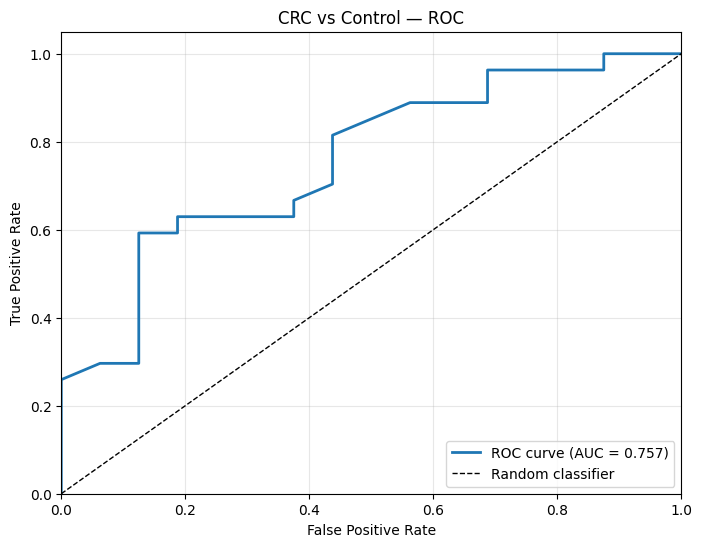

In [11]:
fig = mf.plot_roc(y_test, y_proba, title="CRC vs Control — ROC")
plt.show()

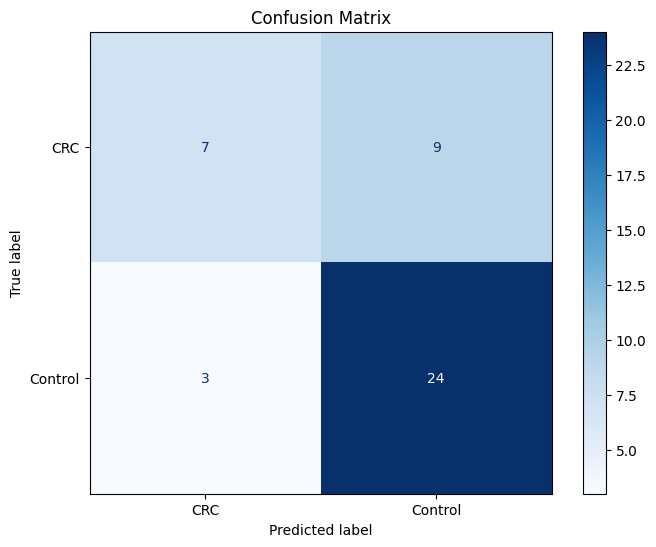

In [12]:
fig = mf.plot_confusion_matrix(
    y_test, y_pred, labels=dataset.target_names, title="Confusion Matrix"
)
plt.show()

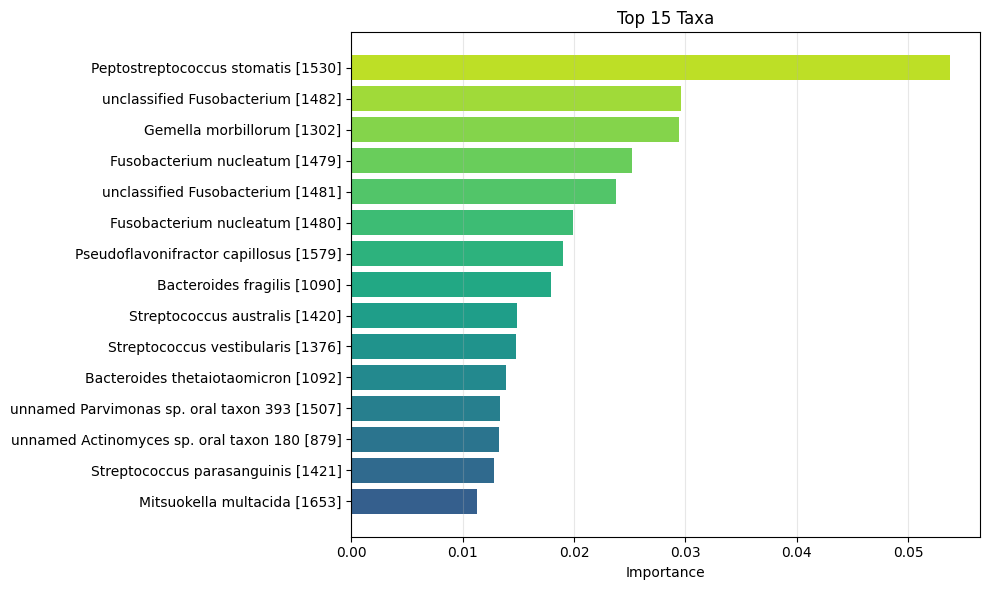

In [13]:
# Map importances back to the feature names that survived preprocessing
kept = model.pipeline_[:-1].get_feature_names_out()
importances = pd.Series(model.feature_importances_, index=kept)
fig = mf.plot_feature_importance(importances, top_n=15, title="Top 15 Taxa")
plt.show()

## 8. Counterfactual explanations (headline feature)

The core question MicroFactual is built to answer: *what minimal change in taxa
abundance would flip this sample's prediction?* We fit a model on CLR-transformed
features, then use the one-call `mf.explain_counterfactual()` API.

Two things make the result **actionable** rather than a wall of numbers:
`sparse=True` (default) reduces each counterfactual to a near-minimal set of taxa
changes that still flips the prediction, and the returned `CounterfactualResult`
exposes `.summary()`, `.changes()`, `.n_changes` and `.validity`.

> Requires the `explainability` extra. If it isn't installed, this section prints a
> hint and is skipped rather than erroring.

In [14]:
# Work in the CLR-transformed feature space so DiCE perturbs the model's actual
# inputs. The preprocessing transforms preserve the real taxon names end-to-end,
# so counterfactuals name actual species (e.g. "Parvimonas micra") rather than
# opaque f0/f1 placeholders — the whole point of an interpretable explanation.
X_clr = CLRTransform().fit_transform(
    PrevalenceFilter(min_prevalence=0.01).fit_transform(
        AbundanceFilter(min_abundance=1e-6).fit_transform(X)
    )
)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clr, y, test_size=0.3, random_state=42, stratify=y
)

# A plain classifier on the already-transformed space (preprocessing=None)
cf_model = mf.MicrobiomeClassifier(algorithm="random_forest", preprocessing=None)
cf_model.fit(Xc_train, yc_train)
print("Counterfactual model trained on", Xc_train.shape[1], "CLR features")

Counterfactual model trained on 321 CLR features


In [15]:
# Explain a sample predicted CRC, so the counterfactual flips it toward Control
# (which keeps the control-plausibility bounds below coherent).
crc_code = list(dataset.target_names).index("CRC")
_crc_idx = np.flatnonzero(cf_model.predict(Xc_test) == crc_code)
query = Xc_test.iloc[[_crc_idx[0]]] if len(_crc_idx) else Xc_test.iloc[[0]]

try:
    print("Prediction for query sample:",
          dataset.target_names[int(cf_model.predict(query)[0])])

    # One call: sparse, validated counterfactuals as a CounterfactualResult.
    cf = mf.explain_counterfactual(
        cf_model,
        query=query,
        background_data=Xc_train,
        y=yc_train,
        total_CFs=3,
        class_names=list(dataset.target_names),
    )
    print(cf.summary())
    display(cf.changes(0).head(10))   # taxa that must change, with direction
except ImportError as e:
    print("Counterfactual section skipped —", e)

Prediction for query sample: CRC


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  2.18it/s]

100%|██████████| 1/1 [00:00<00:00,  2.18it/s]

3 counterfactual(s) flipping CRC → Control; features changed: min=5, median=6, max=8; validity=100%.


,feature,original,counterfactual,delta,direction
0,Sutterella wadsworthensis [469],-2.856930,4.007466,6.864396,increase
1,unnamed Parvimonas sp. oral taxon 110 [1506],2.235422,-2.681913,-4.917335,decrease
2,Enterobacter hormaechei/cloacae [384],-2.856930,1.622021,4.478951,increase
3,Peptostreptococcus stomatis [1530],3.521071,-0.716065,-4.237136,decrease
4,unclassified Fusobacterium [1482],1.100017,-2.681913,-3.781930,decrease
5,Fusobacterium nucleatum [1479],-0.059102,-2.681913,-2.622810,decrease


### Plausible counterfactuals + heatmap

Unconstrained, DiCE can push taxa to values no real sample exhibits.
`mf.plausible_range()` derives per-taxon bounds from the control class and, via
`permitted_range`, keeps the counterfactual in-distribution.
`mf.plot_counterfactual_heatmap()` then shows each changed taxon's original vs.
counterfactual value against the class medians (in control-SD units): a good
counterfactual moves the *Original* column back toward the control centre
without overshooting. `mf.counterfactual_concordance()` scores that movement.

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  3.37it/s]

100%|██████████| 1/1 [00:00<00:00,  3.37it/s]

concordance with Control — unbounded: 100% | bounded: 100%


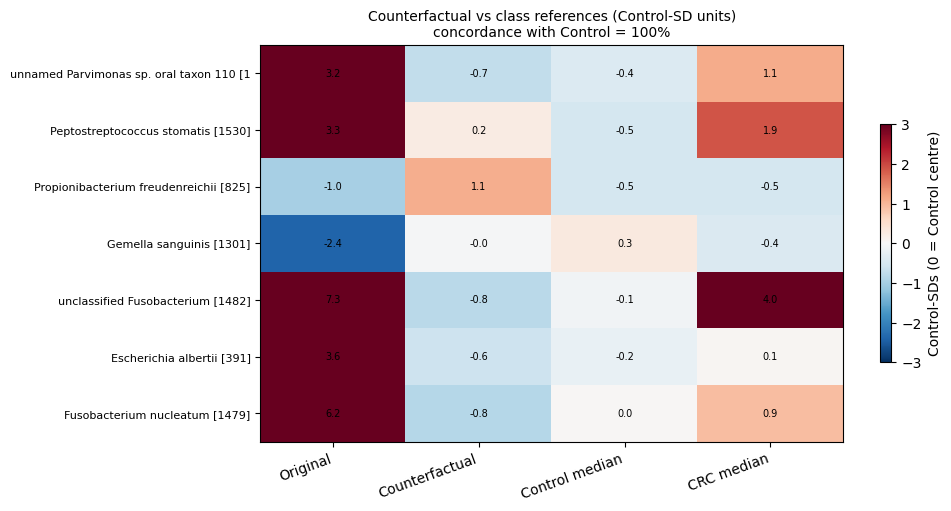

In [16]:
try:
    control = list(dataset.target_names).index("Control")
    crc = list(dataset.target_names).index("CRC")

    # Constrain counterfactuals to the control class's plausible range.
    bounds = mf.plausible_range(Xc_train, yc_train, reference_class=control,
                                q=(0.05, 0.95))
    cf_bounded = mf.explain_counterfactual(
        cf_model, query, background_data=Xc_train, y=yc_train,
        total_CFs=1, class_names=list(dataset.target_names),
        permitted_range=bounds,
    )
    print("concordance with Control — unbounded: {:.0%} | bounded: {:.0%}".format(
        mf.counterfactual_concordance(cf, Xc_train, yc_train, control),
        mf.counterfactual_concordance(cf_bounded, Xc_train, yc_train, control)))

    mf.plot_counterfactual_heatmap(
        cf_bounded, Xc_train, yc_train,
        reference_class=control, comparison_class=crc, top_n=12,
    )
    plt.show()
except ImportError as e:
    print("Plausibility section skipped —", e)
except Exception as e:  # DiCE may find no CF within tight bounds for some samples
    print("No in-bounds counterfactual for this sample —", type(e).__name__)

### Cohort-level counterfactual importance

`mf.counterfactual_importance()` aggregates counterfactuals across many samples
to rank **which taxa most often have to change to flip predictions**, with a net
direction — a local-aggregated importance that complements the global feature
importance from section 7.

In [17]:
try:
    importance = mf.counterfactual_importance(
        cf_model,
        Xc_test.iloc[:15],       # a small cohort, for speed
        yc_train,
        background_data=Xc_train,
        total_CFs=3,
        top_n=10,
    )
    display(importance)
except ImportError as e:
    print("Cohort counterfactual section skipped —", e)

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  2.47it/s]

100%|██████████| 1/1 [00:00<00:00,  2.47it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  2.12it/s]

...

100%|██████████| 1/1 [00:00<00:00,  2.31it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  2.05it/s]

100%|██████████| 1/1 [00:00<00:00,  2.04it/s]

,feature,n_samples,frequency,mean_delta,direction
0,Gemella morbillorum [1302],8,0.533333,3.213718,increase
1,Peptostreptococcus stomatis [1530],8,0.533333,2.920292,increase
2,unnamed Parvimonas sp. oral taxon 110 [1506],7,0.466667,2.684563,increase
3,Escherichia coli [390],7,0.466667,-1.361622,decrease
4,Clostridium symbiosum [1600],6,0.400000,5.896304,increase
5,Eubacterium rectale [1630],6,0.400000,-0.976407,decrease
6,Streptococcus australis [1420],6,0.400000,-3.505908,decrease
7,Parvimonas micra [1505],5,0.333333,4.751266,increase
8,[Ruminococcus] gnavus [1611],5,0.333333,2.819815,increase
9,unclassified Fusobacterium [1482],5,0.333333,1.689221,increase


## 9. Compare algorithms

Same interface, different estimator.

In [18]:
from sklearn.model_selection import cross_val_score

for algo in ["random_forest", "logistic"]:
    scores = cross_val_score(
        mf.MicrobiomeClassifier(algorithm=algo, preprocessing="auto"),
        X, y, cv=5, scoring="roc_auc",
    )
    print(f"{algo:>14}: ROC-AUC {scores.mean():.3f} ± {scores.std():.3f}")

 random_forest: ROC-AUC 0.852 ± 0.071
      logistic: ROC-AUC 0.780 ± 0.108


## Summary

We exercised the full public surface end-to-end on a real CRC dataset:
`MicrobiomeDataset`, the preprocessing transforms, sklearn interop
(`Pipeline`/`cross_validate`/`GridSearchCV`), the `mf.classify()` one-liner,
`MicrobiomeClassifier` train/predict, the visualization helpers, `mf.explore()`
cutoff diagnostics, and actionable `mf.explain_counterfactual()` /
`mf.counterfactual_importance()` counterfactuals.

If every cell above ran without error, the library is healthy end-to-end.